# Validation of spherical harmonics and gravity units
This notebook includes comparison between Lenapy spherical harmonics computation and other existing software.

We validate the forward transforms *sh_to_grid()* against external references grid computed with various software for the same model, constants and truncation. Convergence and agreement are quantified with simple metrology indicators.

**TLDR**: Lenapy spherical harmonics computation is validated within the float machine error range. Recapitulative table with normalized RMSE values:

| Lenapy vs | ICGEM | grates | SHTns |
|---|---|---|---|
| spherical | 4.7×10⁻¹⁵ | 5.5×10⁻¹⁵ | 1.8×10⁻¹⁵ |
| ellipsoidal | 4.7×10⁻¹⁵ | 5.0×10⁻¹⁵ | |

You may want to do futher validation if you are working at high degree (lmax > 1800) and / or close the North / South poles (within a 25km distance radius).

In [1]:
import xarray as xr
import lenapy

import os
import numpy as np
import pandas as pd

# for plotting:
import matplotlib.pyplot as plt

## Legendre functions and potential unit
The best unit to start this validation is geopotential $V$ (m$^2$.s$^{-2})$. It only depends on the "classic" spherical harmonics computation with $\cos$, $\sin$ and Legendre functions $P_{l,m}$. It means that if the computation of Lenapy is closed to other computational software for potential determination, both should be considered as OK for their implementation of the Legendre function (in ***4pi*** normalization) and for the full computation.

\begin{equation}
V(\theta, \lambda) = \sum_{l=0}^{+\infty} \frac{GM}{R} \sum_{m=0}^{n} \lbrack C_{l,m}\cos(m\lambda) + S_{l,m}\sin(m\lambda)\rbrack P_{l,m}(\cos \theta)
\end{equation}

The equivalent formula is given in the [ICGEM documentation](https://icgem.gfz.de/docs/str-0902-revised.pdf) (eq. 108).

This comparaison serves as a validation of the Legendre functions implementation and of the spherical harmonics determination computation.

## Use of ICGEM portal for validation
When using the [ICGEM portal](https://icgem.gfz.de/calcgrid) for validation, we do input the following values for computation:
- Model selection: GO_CONS_GCF_2_DIR_R6.gfc
- Functional selection: potential_ell
- Spatial range: 179.5, 89.5, -89.5, 179.5, 1.0
- Height over Ellipsoid: 0
- Reference System: -user defined-
- Radius: 6378137.0
- Gm: 3.986005e+14
- Flat: 0 if spherical // 298.257222101 if ellipsoidal
- Omega: 7.292115e-5
- Tide system: use model's system (with Zero Degree Term)
- No gentle cut, no Gaussian Filter, usage of all

The resulting grid is downloaded in the .gdf format.

### Spherical case

In [2]:
file_model = '../../data/GO_CONS_GCF_2_DIR_R6.gfc'

ds_ref = xr.open_dataset(file_model, engine='lenapyGfc', no_date=True)

# Convert radius and GM of reference to be coherent with ICGEM computation
ds_ref = ds_ref.lnharmo.change_reference(new_radius=6378137.0, new_earth_gravity_constant=3.986005e14)

# Default ds.attrs radius and earth_gravity_constant are used for the computation (set with change_reference())
grid_lenapy = ds_ref.lnharmo.to_grid(unit='potential', ellipsoidal_earth=False)

grid_lenapy_ellps = ds_ref.lnharmo.to_grid(unit='potential', ellipsoidal_earth=True, f_earth=1/298.257222101)

Mean of differences: -5.6e-10 m².s⁻², RMSE: 2.9e-07 m².s⁻², Normalized RMSE: 4.7e-15


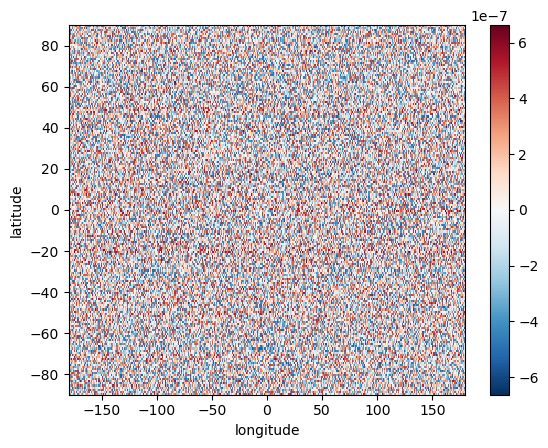

In [3]:
file_icgem = '../../data/potential_ell_GO_CONS_GCF_2_DIR_R6_GRS80sphere.gdf'
df = pd.read_csv(
    file_icgem,
    skiprows=36,
    sep=r"\s+",
    names=["longitude", "latitude", "potential"]
)

grid_icgem = df.set_index(["latitude", "longitude"]).to_xarray().potential

(grid_lenapy - grid_icgem).plot()
plt.title('')

rmse = ((grid_lenapy - grid_icgem)**2).mean()**.5
print(f"Mean of differences: {(grid_lenapy - grid_icgem).mean():.1e} m².s⁻², RMSE: {rmse:.1e} m².s⁻², Normalized RMSE: {rmse / (grid_lenapy**2).mean()**.5:.1e}")

The mean difference of −5.6×10⁻¹⁰ m²·s⁻² indicates a negligible systematic bias, while the RMSE of 2.9×10⁻⁷ m²·s⁻² shows that absolute discrepancies are small compared with the magnitude of the gravitational potential on the grid.
Moreover, the normalized RMSE of 4.7×10⁻¹⁵ places the residual essentially at the round‑off level for double precision, i.e., only a few multiples of float machine epsilon (≈2.22×10⁻¹⁶). No spatial pattern appears in the difference.

Regarding more specific degree amplitude. At $l=300$, the resulting potential has an amplitude of 0.2 so a residual error of 10⁻⁶. At $m=300$, the resulting potential has an amplitude of 0.01 so a residual error of 2×10⁻⁵.

### Ellipsoidal case

Mean of differences: 1.8e-09 m².s⁻², RMSE: 2.9e-07 m².s⁻², Normalized RMSE: 4.7e-15


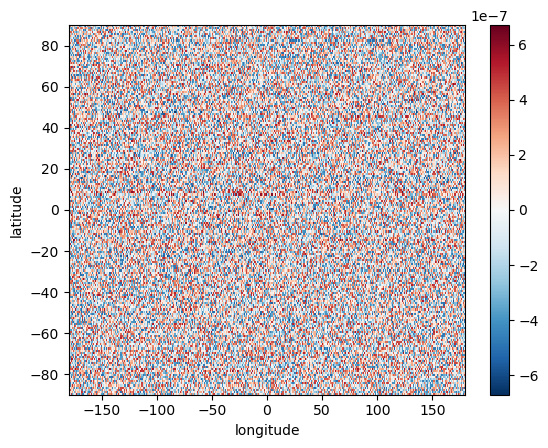

In [4]:
file_icgem_ellps = '../../data/potential_ell_GO_CONS_GCF_2_DIR_R6_GRS80ellps.gdf'
df = pd.read_csv(
    file_icgem_ellps,
    skiprows=36,
    sep=r"\s+",
    names=["longitude", "latitude", "potential"]
)

grid_icgem_ellps = df.set_index(["latitude", "longitude"]).to_xarray().potential

(grid_lenapy_ellps - grid_icgem_ellps).plot()
plt.title('')

rmse = ((grid_lenapy_ellps - grid_icgem_ellps)**2).mean()**.5
print(f"Mean of differences: {(grid_lenapy_ellps - grid_icgem_ellps).mean():.1e} m².s⁻², RMSE: {rmse:.1e} m².s⁻², Normalized RMSE: {rmse / (grid_lenapy_ellps**2).mean()**.5:.1e}")

The mean difference of 1.8×10⁻⁹ m²·s⁻² indicates a negligible systematic bias, while the RMSE of 2.9×10⁻⁷ m²·s⁻² shows that absolute discrepancies are small compared with the magnitude of the gravitational potential on the grid.
Moreover, the normalized RMSE of 4.7×10⁻¹⁵ places the residual essentially at the round‑off level for double precision, i.e., only a few multiples of float machine epsilon (≈2.22×10⁻¹⁶). No spatial pattern appears in the difference.

Regarding more specific degree amplitude. At $l=300$, the resulting potential has an amplitude of 0.2 so a residual error of 10⁻⁶. At $m=300$, the resulting potential has an amplitude of 0.01 so a residual error of 2×10⁻⁵.

### Additional validation made
Not shown here but comparison have been made on the model EIGEN-6C4 with the ICGEM by going to larger $l_{max}$ values up to 2190.

The same errors patterns appears and the RMSE stay at a level of 10⁻⁷ m²·s⁻².

It is not possible to remove degree 2 from the ICGEM portal computation so this validation is limited float machine epsilon limit.

## Grates validation
Then comes validation with the Python [grates library](https://github.com/akvas/grates).
### Spherical case

In [5]:
try:
    import grates
    grates_import = True
    
except ModuleNotFoundError:
    grates_import = False

Mean of differences: -3.0e-09 m².s⁻², RMSE: 6.7e-08 m².s⁻², Normalized RMSE: 1.1e-15


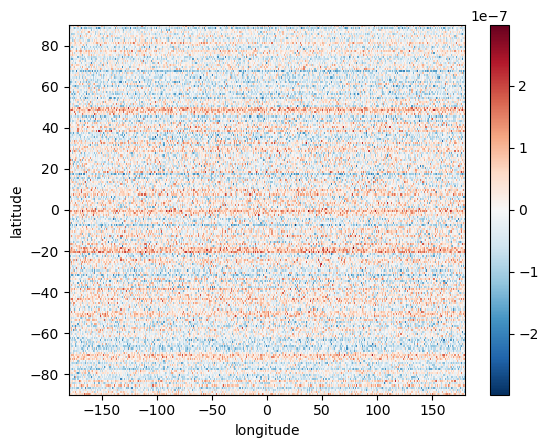

In [6]:
if grates_import:
    sh_grates = grates.io.loadgfc(file_model)
    
    grid_grates = sh_grates.to_grid(grid=grates.grid.GeographicGrid(1, 1, a=6378137.0, f=0), kernel='potential')

    da_grates = xr.DataArray(grid_grates.value_array[::-1], coords={"latitude": grid_lenapy.latitude, "longitude": grid_lenapy.longitude},
                             dims=("latitude", "longitude"))
    
    (grid_lenapy - da_grates).plot()
    plt.title('')

    rmse = ((grid_lenapy - da_grates)**2).mean()**.5
    print(f"Mean of differences: {(grid_lenapy - da_grates).mean():.1e} m².s⁻², RMSE: {rmse:.1e} m².s⁻², Normalized RMSE: {rmse / (grid_lenapy**2).mean()**.5:.1e}")

The mean difference is −3×10⁻⁹ m²·s⁻², while the RMSE of 6.7×10⁻⁸ m²·s⁻² shows that absolute discrepancies are small compared with the magnitude of the gravitational potential on the grid.
Moreover, the normalized RMSE of 1.1×10⁻¹⁵ places the residual essentially at the round‑off level for double precision, i.e., only a few multiples of float machine epsilon (≈2.22×10⁻¹⁶). No spatial pattern appears in the difference.

Regarding more specific degree amplitude. At $l=300$, the resulting potential has an amplitude of 0.2 so a residual error of 3×10⁻⁷. At $m=300$, the resulting potential has an amplitude of 0.01 so a residual error of 7×10⁻⁶.

### Ellipsoidal case

Mean of differences: -1.2e-09 m².s⁻², RMSE: 6.6e-08 m².s⁻², Normalized RMSE: 1.1e-15


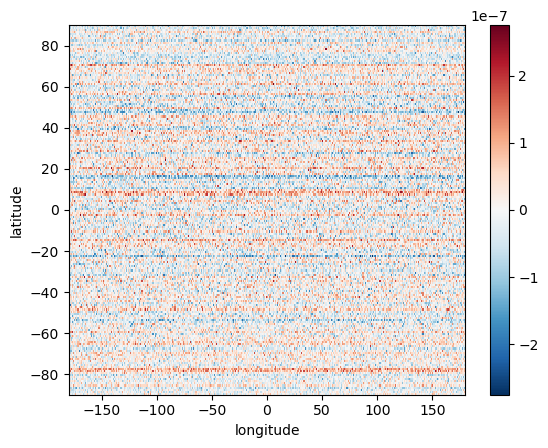

In [7]:
if grates_import:
    grid_grates_ellps = sh_grates.to_grid(grid=grates.grid.GeographicGrid(1, 1, a=6378137.0, f=1/298.257222101), kernel='potential')

    da_grates_ellps = xr.DataArray(grid_grates_ellps.value_array[::-1], coords={"latitude": grid_lenapy.latitude, "longitude": grid_lenapy.longitude},
                             dims=("latitude", "longitude"))
    
    (grid_lenapy_ellps - da_grates_ellps).plot()
    plt.title('')

    rmse = ((grid_lenapy_ellps - da_grates_ellps)**2).mean()**.5
    print(f"Mean of differences: {(grid_lenapy_ellps - da_grates_ellps).mean():.1e} m².s⁻², RMSE: {rmse:.1e} m².s⁻², Normalized RMSE: {rmse / (grid_lenapy_ellps**2).mean()**.5:.1e}")

The mean difference is −1.2×10⁻⁹ m²·s⁻², while the RMSE of 6.6×10⁻⁸ m²·s⁻² shows that absolute discrepancies are small compared with the magnitude of the gravitational potential on the grid.
Moreover, the normalized RMSE of 1.1×10⁻¹⁵ places the residual essentially at the round‑off level for double precision, i.e., only a few multiples of float machine epsilon (≈2.22×10⁻¹⁶). No spatial pattern appears in the difference.

Regarding more specific degree amplitude. At $l=300$, the resulting potential has an amplitude of 0.2 so a residual error of 3×10⁻⁷. At $m=300$, the resulting potential has an amplitude of 0.01 so a residual error of 7×10⁻⁶.

### With degree > 2
We remove degree 0 and 2 to reduce the maximal value of the spatial gravity field. It allows us to validate futher the estimation of Lenapy against grates.

Mean of differences: 4.2e-15 m².s⁻², RMSE: 1.3e-12 m².s⁻², Normalized RMSE: 5.5e-15


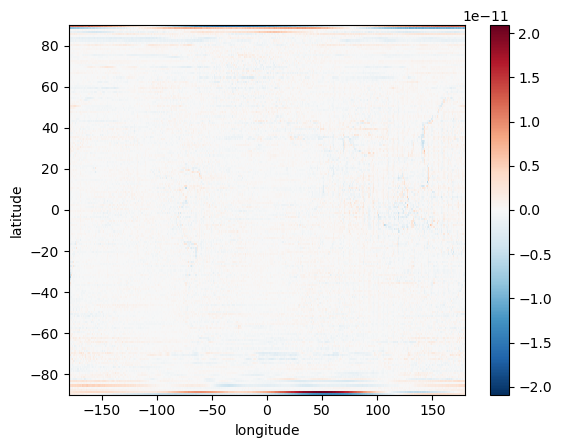

In [8]:
if grates_import:
    lmin = 3
    
    grid_lenapy = ds_ref.sel(l=slice(lmin, None)).lnharmo.to_grid(unit='potential', ellipsoidal_earth=False)
    
    sh_grates = grates.io.loadgfc(file_model)

    sh_grates.anm[:lmin, :lmin] = 0
    
    grid_grates = sh_grates.to_grid(grid=grates.grid.GeographicGrid(1, 1, a=6378137.0, f=0), kernel='potential')

    da_grates = xr.DataArray(grid_grates.value_array[::-1], coords={"latitude": grid_lenapy.latitude, "longitude": grid_lenapy.longitude},
                             dims=("latitude", "longitude"))
    
    (grid_lenapy - da_grates).plot()
    plt.title('')

    rmse = ((grid_lenapy - da_grates)**2).mean()**.5
    print(f"Mean of differences: {(grid_lenapy - da_grates).mean():.1e} m².s⁻², RMSE: {rmse:.1e} m².s⁻², Normalized RMSE: {rmse / (grid_lenapy**2).mean()**.5:.1e}")

The mean difference is 4.2×10⁻¹⁵ m²·s⁻², while the RMSE of 1.3×10⁻¹² m²·s⁻² shows that absolute discrepancies are small compared with the magnitude of the gravitational potential on the grid.
Moreover, the normalized RMSE of 5.5×10⁻¹⁵ places the residual one order of magnitude above the level for double precision / float machine epsilon (≈2.22×10⁻¹⁶). Difference are larger at high latitude indicating small errors due to rounding errors (from either Lenapy or grates). We also see the signature of areas with the largest signals like Indonesia and Andes mountains but at a smaller amplitude than the high latitude differences.

Regarding more specific degree amplitude. At $l=300$, the resulting potential has an amplitude of 0.2 so a residual error of 6×10⁻¹². At $m=300$, the resulting potential has an amplitude of 0.01 so a residual error of 1.3×10⁻¹⁰.

### With degree > 2 on ellipsoid

Mean of differences: -2.6e-14 m².s⁻², RMSE: 1.2e-12 m².s⁻², Normalized RMSE: 5.0e-15


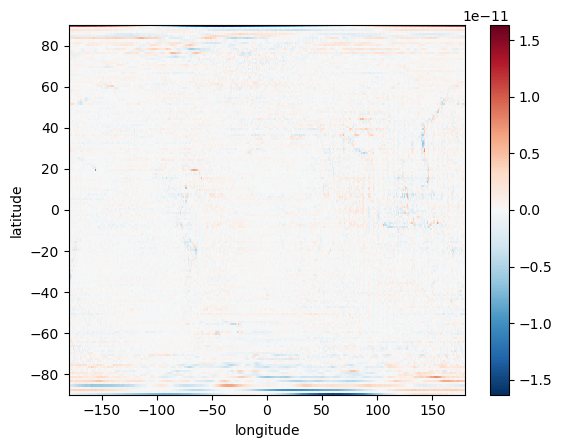

In [9]:
if grates_import:
    lmin = 3
    
    grid_lenapy_ellps = grid_lenapy = ds_ref.sel(l=slice(lmin, None)).lnharmo.to_grid(unit='potential', ellipsoidal_earth=True, f_earth=1/298.257222101)
    
    sh_grates_ellps = grates.io.loadgfc(file_model)

    sh_grates_ellps.anm[:lmin, :lmin] = 0
    
    grid_grates_ellps = sh_grates_ellps.to_grid(grid=grates.grid.GeographicGrid(1, 1, a=6378137.0, f=1/298.257222101), kernel='potential')

    da_grates_ellps = xr.DataArray(grid_grates_ellps.value_array[::-1], coords={"latitude": grid_lenapy_ellps.latitude, "longitude": grid_lenapy_ellps.longitude},
                             dims=("latitude", "longitude"))
    
    (grid_lenapy_ellps - da_grates_ellps).plot()
    plt.title('')

    rmse = ((grid_lenapy_ellps - da_grates_ellps)**2).mean()**.5
    print(f"Mean of differences: {(grid_lenapy_ellps - da_grates_ellps).mean():.1e} m².s⁻², RMSE: {rmse:.1e} m².s⁻², Normalized RMSE: {rmse / (grid_lenapy_ellps**2).mean()**.5:.1e}")

The mean difference is −2.6×10⁻¹⁴ m²·s⁻², while the RMSE of 1.2×10⁻¹² m²·s⁻² shows that absolute discrepancies are small compared with the magnitude of the gravitational potential on the grid.
Moreover, the normalized RMSE of 5×10⁻¹⁵ places the residual one order of magnitude above the level for double precision / float machine epsilon (≈2.22×10⁻¹⁶). Difference are larger at high latitude indicating small errors due to rounding errors (from either Lenapy or grates). We also see the signature of areas with the largest signals like Indonesia and Andes mountains but at a smaller amplitude than the high latitude differences.

Regarding more specific degree amplitude. At $l=300$, the resulting potential has an amplitude of 0.2 so a residual error of 6×10⁻¹². At $m=300$, the resulting potential has an amplitude of 0.01 so a residual error of 1.3×10⁻¹⁰.

## SHTns validation
### Full degree validation
Then comes validation with the Python [shtns library](https://nschaeff.bitbucket.io/shtns/).

In [10]:
try:
    import shtns
    shtns_import = True
    
except ModuleNotFoundError:
    shtns_import = False

[SHTns 3.7.4] built Jan 29 2026, 12:15:08, id: avx2,ishioka


Mean of differences: 4.8e-09 m².s⁻², RMSE: 5.1e-08 m².s⁻², Normalized RMSE: 8.2e-16


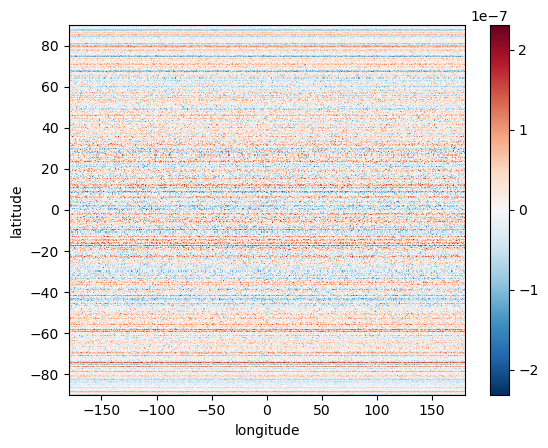

In [11]:
if shtns_import:
    lmax = 300
    mmax = 300
    
    # adapt the output lenapy grid for the comparison
    grid_lenapy = ds_ref.sel(l=slice(0,lmax), m=slice(0,mmax)).lnharmo.to_grid(unit='potential', ellipsoidal_earth=False, longitude=np.arange(-179.5, 180.5, 0.5), latitude=np.arange(-89.75, 90, 0.5))
    
    # create shtns object with given lmax and mmax (4pi normalized)
    sh = shtns.sht(lmax, mmax, norm=shtns.sht_fourpi)  
    
    # build regular latitude grid (with sufficient size to not raise any error)
    nlat, nphi = sh.set_grid(360, 720, shtns.sht_reg_fast)
    
    # build the Ylm array for shtns
    ylm = np.zeros((len(sh.l))).astype(dtype=complex)
    for i in range(len(sh.l)):
        if sh.m[i]==0:
            ylm[i] = ds_ref.clm.sel(l=sh.l[i], m=sh.m[i]).values[0]
        else:
            # adaptation if m != 0 to take into account the Kronecker delta from gravimetry
            ylm[i] = (ds_ref.clm.sel(l=sh.l[i], m=sh.m[i]).values[0] + 1j*ds_ref.slm.sel(l=sh.l[i], m=sh.m[i]).values[0])/np.sqrt(2)
    
    # transform sh description of Ylm into spatial representation
    grid_shtns = sh.synth(ylm)*ds_ref.earth_gravity_constant/ds_ref.radius
    
    da_shtns = xr.DataArray(grid_shtns[::-1, ::-1], coords={"latitude": grid_lenapy.latitude, "longitude": grid_lenapy.longitude},
                                 dims=("latitude", "longitude"))
    
    
    (grid_lenapy - da_shtns).plot()
    plt.title('')
    
    rmse = ((grid_lenapy - da_shtns)**2).mean()**.5
    print(f"Mean of differences: {(grid_lenapy - da_shtns).mean():.1e} m².s⁻², RMSE: {rmse:.1e} m².s⁻², Normalized RMSE: {rmse / (grid_shtns**2).mean()**.5:.1e}")

The mean difference is 4.8×10⁻⁹ m²·s⁻² while the RMSE of 5.1×10⁻⁸ m²·s⁻² shows that absolute discrepancies are small compared with the magnitude of the gravitational potential on the grid.
Moreover, the normalized RMSE of 8.2×10⁻¹⁶ places the residual essentially at the round‑off level for double precision, i.e., only a few multiples of float machine epsilon (≈2.22×10⁻¹⁶). No spatial pattern appears in the difference.

Regarding more specific degree amplitude. At $l=300$, the resulting potential has an amplitude of 0.2 so a residual error of 3×10⁻⁷. At $m=300$, the resulting potential has an amplitude of 0.01 so a residual error of 5×10⁻⁶.

### With degree > 2
We remove degree 0 and 2 to reduce the maximal value of the spatial gravity field. It allows us to validate futher the estimation of Lenapy against grates.

Mean of differences: 2.9e-14 m².s⁻², RMSE: 4.5e-13 m².s⁻², Normalized RMSE: 1.8e-15


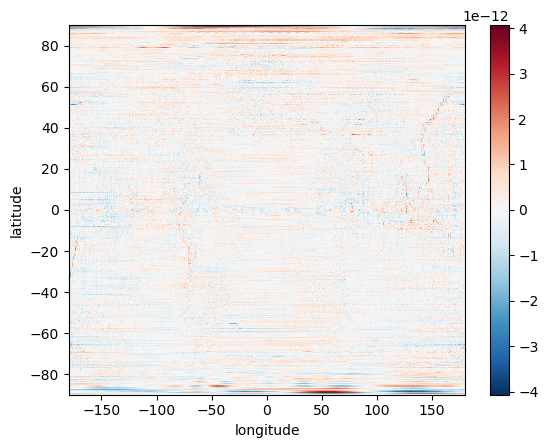

In [12]:
if shtns_import:
    lmin = 3
    
    lmax = 300
    mmax = 300
    
    # adapt the output lenapy grid for the comparison
    grid_lenapy = ds_ref.sel(l=slice(lmin,lmax), m=slice(0,mmax)).lnharmo.to_grid(unit='potential', ellipsoidal_earth=False, longitude=np.arange(-179.5, 180.5, 0.5), latitude=np.arange(-89.75, 90, 0.5))
    
    # create shtns object with given lmax and mmax (4pi normalized)
    sh = shtns.sht(lmax, mmax, norm=shtns.sht_fourpi)  
    
    # build regular latitude grid (with sufficient size to not raise any error)
    nlat, nphi = sh.set_grid(360, 720, shtns.sht_reg_fast)
    
    # build the Ylm array for shtns
    ylm = np.zeros((len(sh.l))).astype(dtype=complex)
    for i in range(len(sh.l)):
        if sh.l[i] >= lmin:
            if sh.m[i]==0:
                ylm[i] = ds_ref.clm.sel(l=sh.l[i], m=sh.m[i]).values[0]
            else:
                # adaptation if m != 0 to take into account the Kronecker delta from gravimetry
                ylm[i] = (ds_ref.clm.sel(l=sh.l[i], m=sh.m[i]).values[0] + 1j*ds_ref.slm.sel(l=sh.l[i], m=sh.m[i]).values[0])/np.sqrt(2)
    
    # transform sh description of Ylm into spatial representation
    grid_shtns = sh.synth(ylm)*ds_ref.earth_gravity_constant/ds_ref.radius
    
    da_shtns = xr.DataArray(grid_shtns[::-1, ::-1], coords={"latitude": grid_lenapy.latitude, "longitude": grid_lenapy.longitude},
                                 dims=("latitude", "longitude"))
    
    
    (grid_lenapy - da_shtns).plot()
    plt.title('')
    
    rmse = ((grid_lenapy - da_shtns)**2).mean()**.5
    print(f"Mean of differences: {(grid_lenapy - da_shtns).mean():.1e} m².s⁻², RMSE: {rmse:.1e} m².s⁻², Normalized RMSE: {rmse / (grid_shtns**2).mean()**.5:.1e}")

The mean difference is 2.9×10⁻¹⁴ m²·s⁻², while the RMSE of 4.5×10⁻¹³ m²·s⁻² shows that absolute discrepancies are small compared with the magnitude of the gravitational potential on the grid.
Moreover, the normalized RMSE of 1.8×10⁻¹⁵ places the residual essentially at the round‑off level for double precision, i.e., only a few multiples of float machine epsilon (≈2.22×10⁻¹⁶). Difference are larger at high latitude indicating small errors due to rounding errors (from either Lenapy or shtns). We also see the signature of areas with the largest signals like Indonesia and Andes mountains but at a smaller amplitude than the high latitude differences.

Regarding more specific degree amplitude. At $l=300$, the resulting potential has an amplitude of 0.2 so a residual error of 2×10⁻¹². At $m=300$, the resulting potential has an amplitude of 0.01 so a residual error of 4.5×10⁻¹¹.

## Summary
No significant numerical instability was observed for $l_{max} \leq 300$ (and for $\leq 2000$ but not shown here). Lenapy was validated against ICGEM, grates and shtns.

Mostly valid within the double float machine precision in every case. Slight deviations above machine precision were observed between lenapy and grates at high latitudes. The closer agreement between lenapy and shtns suggests that the larger instabilities originate from the grates implementation.

Minor discrepancies were also detected between lenapy and shtns; however, they remain below the threshold required to be distinguished from floating-point precision errors. These differences may indicate a very small numerical instability in lenapy under extreme conditions.
Except for computations performed extremely close to the North or South Pole, no further analysis is required.